# Customer Segmentation with RFM Analysis

## Project Overview

This project analyzes customer transaction data using RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior.

The analysis aims to identify valuable, loyal, inactive, and at-risk customer groups that can support customer retention and marketing decisions.

### Objectives

- Understand customer transaction data
- Clean and preprocess transaction records
- Calculate Recency, Frequency, and Monetary metrics
- Create RFM scores
- Segment customers based on purchasing behavior
- Visualize customer segments
- Generate business recommendations

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


In [57]:
df = pd.read_csv("/content/online_retail.csv")

In [58]:
df.shape

(541909, 8)

In [59]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [61]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [62]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Description,1454
CustomerID,135080


In [63]:
missing_customer = df["CustomerID"].isnull().sum()

print("Missing CustomerID:", missing_customer)

Missing CustomerID: 135080


In [64]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [65]:
df = df.dropna(subset=["CustomerID"])

In [66]:
df.shape

(406829, 8)

In [67]:
df["Quantity"].describe()

,Quantity
count,406829.000000
mean,12.061303
std,248.693370
min,-80995.000000
25%,2.000000
50%,5.000000
75%,12.000000
max,80995.000000


In [68]:
print("Negative Quantity:", (df["Quantity"] < 0).sum())

Negative Quantity: 8905


In [69]:
df = df[df["Quantity"] > 0]

In [70]:
print("Zero UnitPrice:", (df["UnitPrice"] <= 0).sum())

Zero UnitPrice: 40


In [71]:
df = df[df["UnitPrice"] > 0]

In [72]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [73]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [74]:
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

In [75]:
df[
    ["Quantity", "UnitPrice", "TotalSales"]
].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [76]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [77]:
rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalSales", "sum")
    )
    .reset_index()
)

In [78]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [79]:
rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


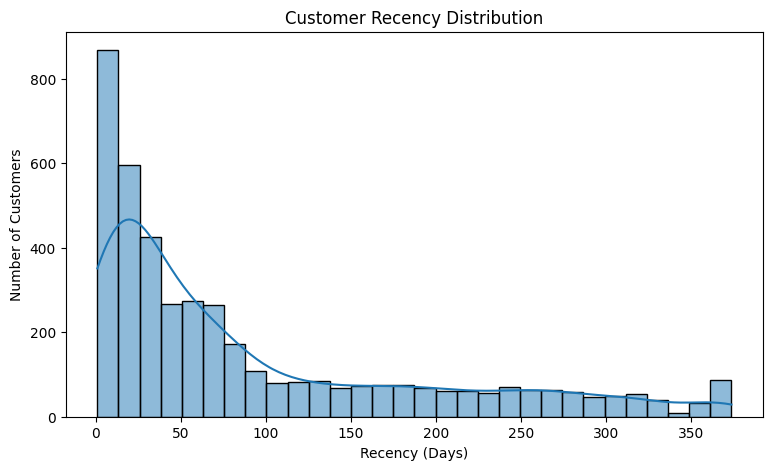

In [80]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=rfm,
    x="Recency",
    bins=30,
    kde=True
)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

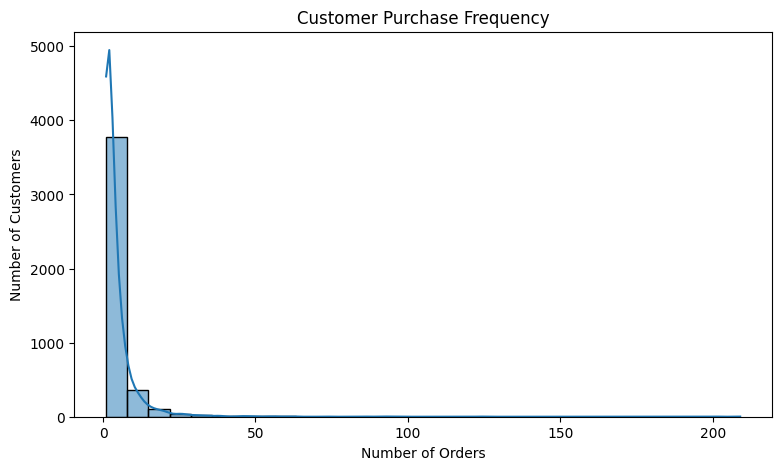

In [81]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=rfm,
    x="Frequency",
    bins=30,
    kde=True
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

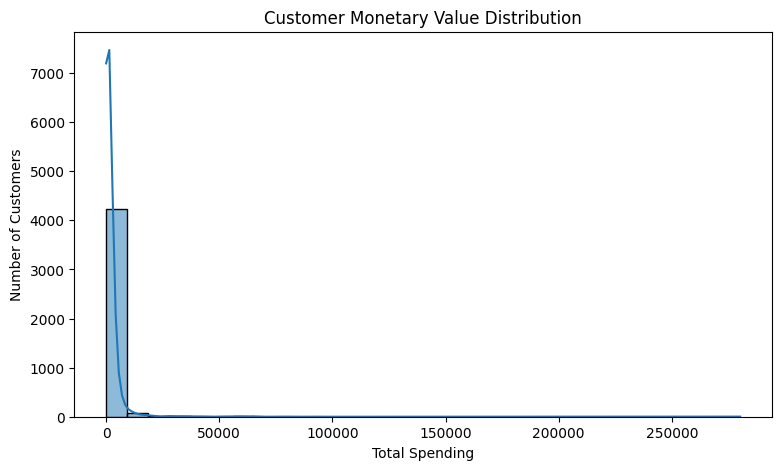

In [82]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=rfm,
    x="Monetary",
    bins=30,
    kde=True

)

plt.title("Customer Monetary Value Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

In [83]:
df.shape

(397884, 9)

In [84]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalSales'],
      dtype='object')

In [85]:
missing_values[missing_values > 0]

,0
Description,1454
CustomerID,135080


In [86]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [87]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [88]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [89]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2


In [90]:
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

In [91]:
rfm["RFM_Score"].describe()

,RFM_Score
count,4338.000000
mean,9.015445
std,3.591229
min,3.000000
25%,6.000000
50%,9.000000
75%,12.000000
max,15.000000


In [92]:
def rfm_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 8:
        return "Potential Loyalists"
    elif score >= 6:
        return "Need Attention"
    else:
        return "At Risk"

rfm["Segment"] = rfm["RFM_Score"].apply(rfm_segment)

In [93]:
rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "RFM_Score",
        "Segment"
    ]
].head(10)

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment
0,12346.0,326,1,77183.60,7,Need Attention
1,12347.0,2,7,4310.00,15,Champions
2,12348.0,75,4,1797.24,10,Loyal Customers
3,12349.0,19,1,1757.55,9,Potential Loyalists
4,12350.0,310,1,334.40,4,At Risk
5,12352.0,36,8,2506.04,13,Champions
6,12353.0,204,1,89.00,3,At Risk
7,12354.0,232,1,1079.40,6,Need Attention
8,12355.0,214,1,459.40,4,At Risk
9,12356.0,23,3,2811.43,12,Loyal Customers


In [94]:
segment_count = (
    rfm["Segment"]
    .value_counts()
)

segment_count

,count
Segment,
Loyal Customers,1008
Champions,934
At Risk,883
Need Attention,800
Potential Loyalists,713


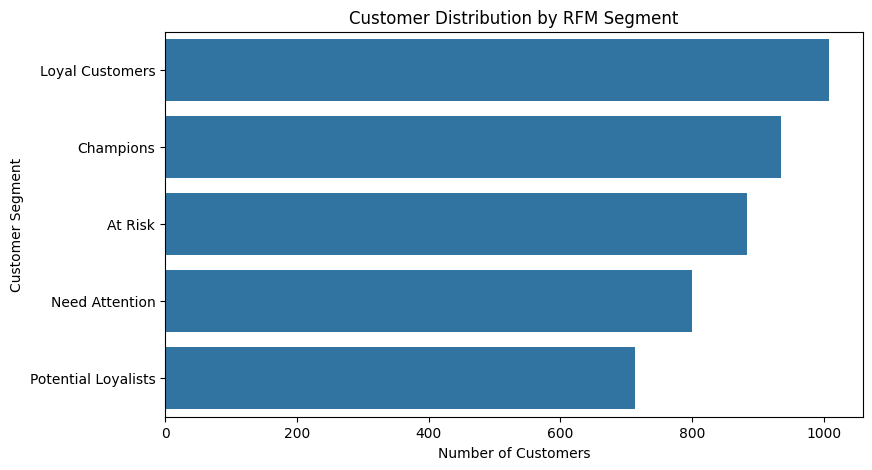

In [95]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=segment_count.values,
    y=segment_count.index
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.show()

In [96]:
segment_percentage = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

,proportion
Segment,
Loyal Customers,23.24
Champions,21.53
At Risk,20.36
Need Attention,18.44
Potential Loyalists,16.44


In [97]:
segment_profile = (
    rfm.groupby("Segment")
    .agg(
        customers=("CustomerID", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean")
    )
    .sort_values("avg_monetary", ascending=False)
)

segment_profile

,customers,avg_recency,avg_frequency,avg_monetary
Segment,,,,
Champions,934,14.614561,11.739829,6697.362452
Loyal Customers,1008,43.420635,3.860119,1397.450309
Potential Loyalists,713,78.844320,2.237027,861.461532
Need Attention,800,111.397500,1.447500,537.243614
At Risk,883,224.995470,1.045300,230.378822


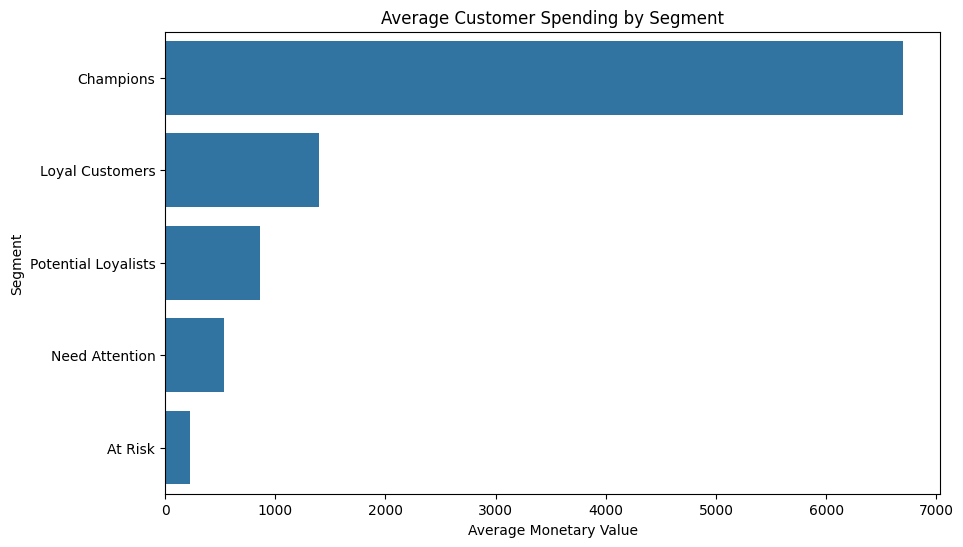

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile.reset_index(),
    x="avg_monetary",
    y="Segment"
)

plt.title("Average Customer Spending by Segment")
plt.xlabel("Average Monetary Value")
plt.ylabel("Segment")

plt.show()

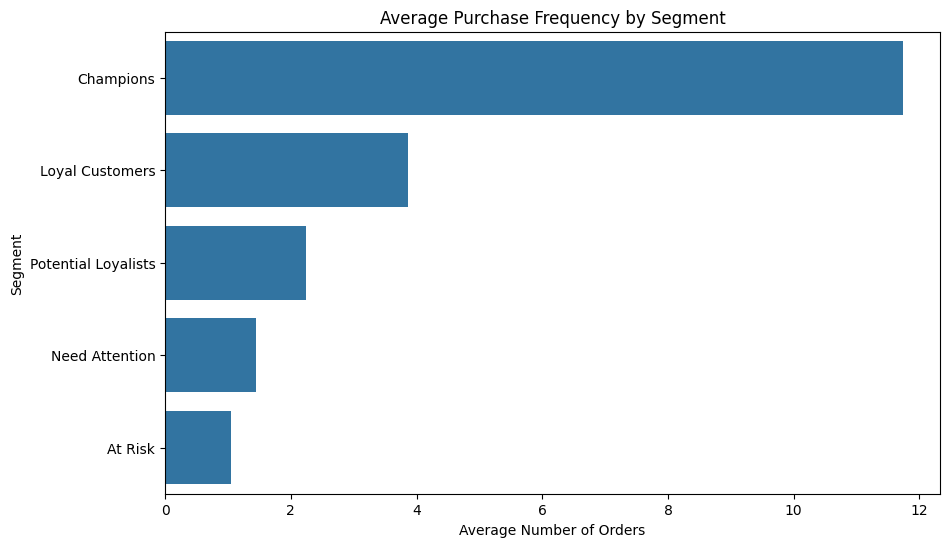

In [99]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile.reset_index(),
    x="avg_frequency",
    y="Segment"
)

plt.title("Average Purchase Frequency by Segment")
plt.xlabel("Average Number of Orders")
plt.ylabel("Segment")

plt.show()

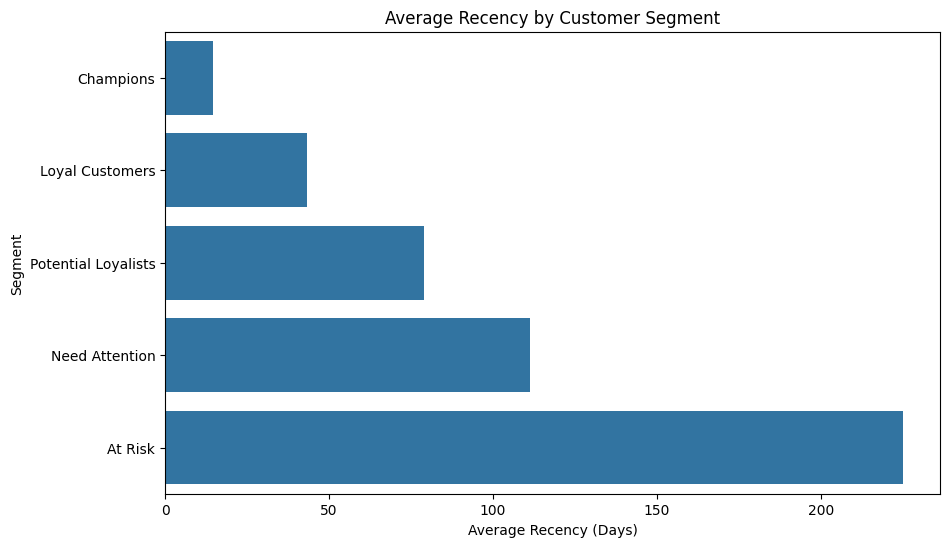

In [100]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile.reset_index(),
    x="avg_recency",
    y="Segment"
)

plt.title("Average Recency by Customer Segment")
plt.xlabel("Average Recency (Days)")
plt.ylabel("Segment")

plt.show()

In [101]:
top_customers = (
    rfm.sort_values(
        ["RFM_Score", "Monetary"],
        ascending=[False, False]
    )
    .head(10)
)

top_customers

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1689,14646.0,2,73,280206.02,5,5,5,15,Champions
4201,18102.0,1,60,259657.30,5,5,5,15,Champions
3728,17450.0,8,46,194550.79,5,5,5,15,Champions
1879,14911.0,1,201,143825.06,5,5,5,15,Champions
1333,14156.0,10,55,117379.63,5,5,5,15,Champions
3771,17511.0,3,31,91062.38,5,5,5,15,Champions
3176,16684.0,4,28,66653.56,5,5,5,15,Champions
1289,14096.0,4,17,65164.79,5,5,5,15,Champions
996,13694.0,4,50,65039.62,5,5,5,15,Champions
2176,15311.0,1,91,60767.90,5,5,5,15,Champions


In [102]:
segment_count

,count
Segment,
Loyal Customers,1008
Champions,934
At Risk,883
Need Attention,800
Potential Loyalists,713


In [103]:
segment_percentage

,proportion
Segment,
Loyal Customers,23.24
Champions,21.53
At Risk,20.36
Need Attention,18.44
Potential Loyalists,16.44


In [104]:
segment_profile

,customers,avg_recency,avg_frequency,avg_monetary
Segment,,,,
Champions,934,14.614561,11.739829,6697.362452
Loyal Customers,1008,43.420635,3.860119,1397.450309
Potential Loyalists,713,78.844320,2.237027,861.461532
Need Attention,800,111.397500,1.447500,537.243614
At Risk,883,224.995470,1.045300,230.378822


In [105]:
top_customers

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1689,14646.0,2,73,280206.02,5,5,5,15,Champions
4201,18102.0,1,60,259657.30,5,5,5,15,Champions
3728,17450.0,8,46,194550.79,5,5,5,15,Champions
1879,14911.0,1,201,143825.06,5,5,5,15,Champions
1333,14156.0,10,55,117379.63,5,5,5,15,Champions
3771,17511.0,3,31,91062.38,5,5,5,15,Champions
3176,16684.0,4,28,66653.56,5,5,5,15,Champions
1289,14096.0,4,17,65164.79,5,5,5,15,Champions
996,13694.0,4,50,65039.62,5,5,5,15,Champions
2176,15311.0,1,91,60767.90,5,5,5,15,Champions


## 6. Business Recommendations

The RFM segmentation provides different customer profiles that require different retention and marketing strategies.

### Champions

Champions are the highest-value customers, with very recent purchases, high purchase frequency, and high spending.

**Recommended strategy:**
- Provide exclusive rewards
- Offer early access to new products
- Create VIP or loyalty benefits
- Encourage referrals and advocacy

### Loyal Customers

Loyal Customers show consistent purchasing behavior but have lower activity and monetary value than Champions.

**Recommended strategy:**
- Provide loyalty rewards
- Use personalized product recommendations
- Offer cross-selling and upselling campaigns
- Encourage customers to increase purchase frequency

### Potential Loyalists

Potential Loyalists have promising purchasing behavior but have not yet reached the level of loyal customers.

**Recommended strategy:**
- Offer personalized promotions
- Encourage a second or third purchase
- Introduce loyalty programs
- Recommend related products

### Need Attention

Need Attention customers show lower purchase frequency and higher recency compared with stronger customer segments.

**Recommended strategy:**
- Send targeted re-engagement campaigns
- Offer limited-time promotions
- Recommend products based on previous purchases
- Monitor whether engagement improves

### At Risk

At Risk customers have very high recency and low purchase frequency and monetary value.

**Recommended strategy:**
- Launch win-back campaigns
- Provide personalized incentives
- Send reminders or special offers
- Identify customers who were previously valuable and prioritize them for retention

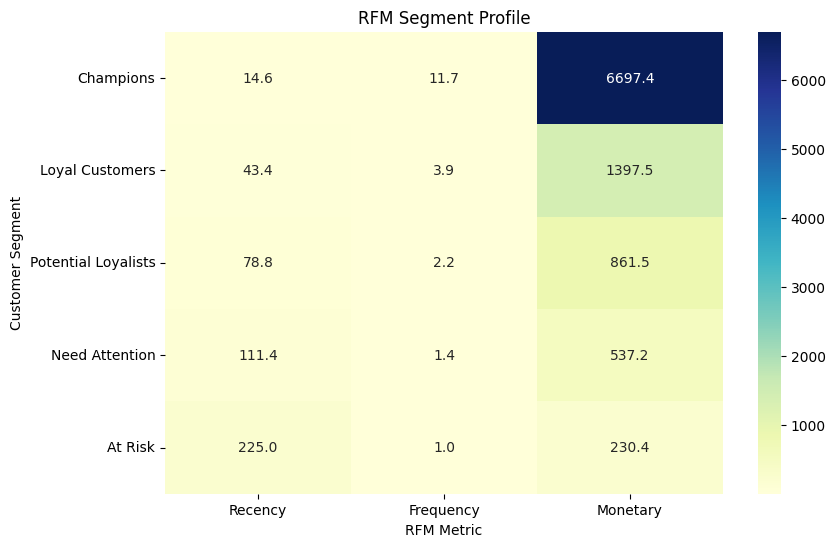

In [106]:
segment_heatmap = segment_profile[
    [
        "avg_recency",
        "avg_frequency",
        "avg_monetary"
    ]
].copy()

segment_heatmap.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    segment_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("RFM Segment Profile")
plt.xlabel("RFM Metric")
plt.ylabel("Customer Segment")

plt.show()

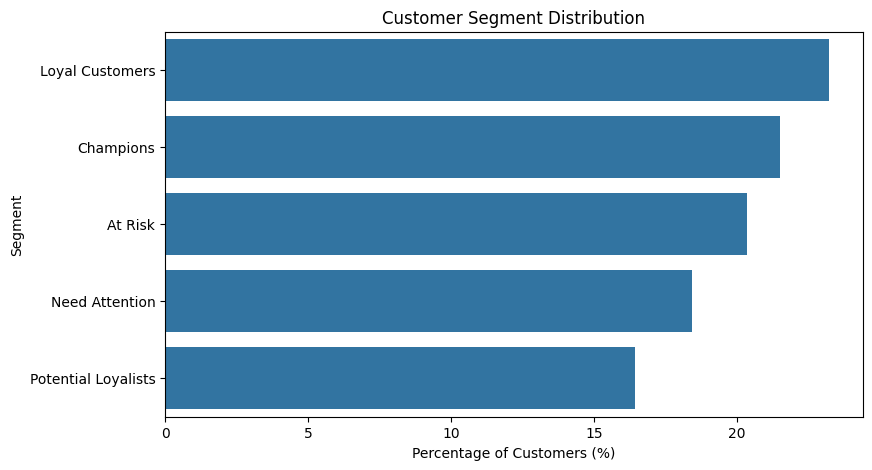

In [107]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=segment_percentage.values,
    y=segment_percentage.index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Percentage of Customers (%)")
plt.ylabel("Segment")

plt.show()

In [108]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

,Monetary
Segment,
Champions,6255336.530
Loyal Customers,1408629.911
Potential Loyalists,614222.072
Need Attention,429794.891
At Risk,203424.500


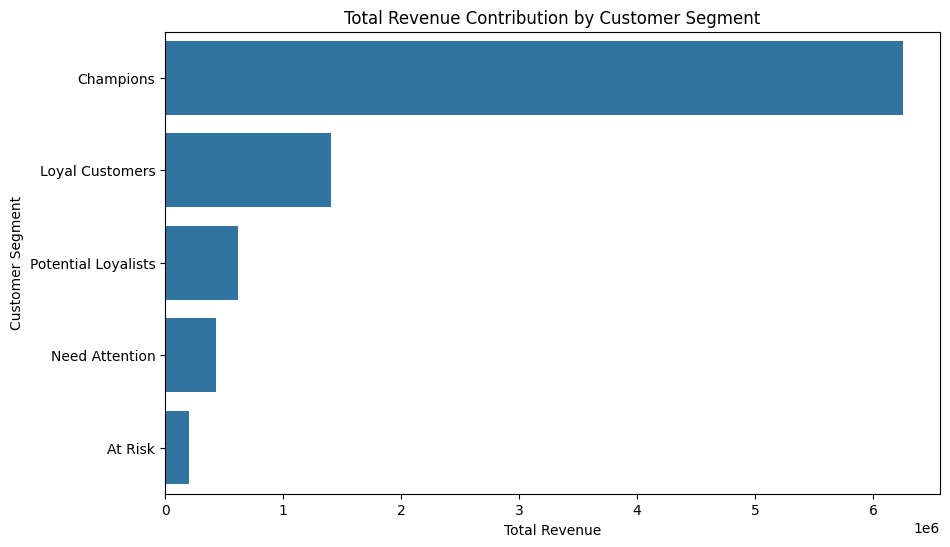

In [109]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_revenue.values,
    y=segment_revenue.index
)

plt.title("Total Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")

plt.show()

In [110]:
top_revenue_segment = segment_revenue.idxmax()
top_revenue = segment_revenue.max()

print("Top Revenue Segment:", top_revenue_segment)
print(f"Total Revenue: {top_revenue:,.2f}")

Top Revenue Segment: Champions
Total Revenue: 6,255,336.53


## 7. Key Findings

### 1. Customer Distribution

Loyal Customers represented the largest customer segment with 1,008 customers or 23.24% of the total customer base.

### 2. Champions

Champions consisted of 934 customers or 21.53% of the customer base. This segment had the strongest customer profile, with the lowest average recency at approximately 14.61 days, the highest average frequency at 11.74 orders, and the highest average monetary value at approximately 6,697.36.

### 3. At Risk Customers

At Risk customers represented 20.36% of the customer base. Their average recency was approximately 225 days, while their average purchase frequency was only 1.05 orders.

### 4. Customer Value

Champions generated the highest average spending per customer and also contributed the highest total revenue, reaching approximately 6,255,336.53. This indicates that Champions are the most valuable customer segment in terms of both individual customer value and overall revenue contribution.

### 5. Business Opportunity

The analysis suggests two major priorities: retain high-value Champions and Loyal Customers while re-engaging At Risk and Need Attention customers to reduce customer inactivity and improve long-term customer value.

## 8. Conclusion

This project applied RFM analysis to segment customers based on Recency, Frequency, and Monetary value.

A total of 4,338 customers were analyzed and grouped into five segments: Champions, Loyal Customers, Potential Loyalists, Need Attention, and At Risk.

Champions showed the strongest purchasing behavior, with recent transactions, high purchase frequency, and high average spending. In contrast, At Risk customers had the longest average recency and the lowest purchasing frequency, indicating a potential customer retention issue.

The segmentation provides a practical framework for designing differentiated customer strategies. High-value customers can be targeted with loyalty and VIP programs, while inactive customers can be targeted with personalized re-engagement and win-back campaigns.

Overall, RFM analysis demonstrates how transaction data can be transformed into actionable customer segments and business recommendations.

Champions emerged as the most valuable segment, contributing approximately 6,255,336.53 in total revenue. This highlights the importance of prioritizing retention strategies for high-value customers while developing targeted re-engagement strategies for inactive segments.